# 03. 細胞株のベースライン糖鎖遺伝子プロファイル PCA

## 目的

薬剤応答（LINCS Level 5 = 同一細胞内の「薬 vs 対照」差分をz化したもの）でPCA/UMAPを描くと
細胞株が完全に混ざった雲になる（`02_epitope_signature_umap.ipynb`, `fig_epitope_pca_bycell`）。
これは失敗ではなく **z化の時点で細胞株ごとのベースラインが引き算されているため当然** である。

細胞株ごとの糖鎖の「素地」の違いを見るには、差分ではなく **対照サンプルの絶対量** を使う必要がある。
本ノートはそれを行う。

## データ

`RAW.LINCS.CTL_GLYCO_GENES_WIDE`（対照 188,708 サンプル × glycogene 385）。
LINCS DCIC 2021 の predicted RNA-seq 由来。細胞株は `SAMPLE_ID` の第2トークンに埋まっている。

## 注意した交絡

LINCS の対照サンプルはプロジェクト（`CPC005` 等）ごとに走っており、細胞株とプロジェクトが交絡する。
そのため以下を行う：

1. ロバストzで外れ値試料を除去
2. **5細胞株以上が共有するプロジェクト**に限定
3. プレート単位で集約（4ウェル以上）
4. **3細胞株以上を含むプロジェクト**に限定し、プロジェクト平均で中心化
5. 分散分解で「細胞株が説明する割合」がバッチ除去後も残ることを確認

関連: `docs/set_based_aggregation_feasibility.md`, `docs/lincs_data_inventory.md`

In [1]:
import subprocess, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rcParams['font.family'] = ['Hiragino Sans', 'sans-serif']
rcParams['axes.unicode_minus'] = False
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'

ROOT = pathlib.Path('/Users/koreedatatsuya/research/glyco_epitope_3rd_paper')
CACHE = ROOT / 'data' / 'processed' / 'ctl_glyco_baseline.csv'
FIGDIR = ROOT / 'results' / 'figures'
CACHE.parent.mkdir(parents=True, exist_ok=True)


def savefig(name):
    """成果物ごとのフォルダに PNG/PDF/SVG を保存する（/figure-style の規約）"""
    outdir = FIGDIR / name
    outdir.mkdir(parents=True, exist_ok=True)
    for ext in ('png', 'pdf', 'svg'):
        plt.savefig(outdir / f'{name}.{ext}', dpi=200, bbox_inches='tight')

## 1. Snowflake から対照サンプルを取得

細胞株ごとに最大400試料をランダム抽出（seed 固定）。初回のみ実行され、以後はキャッシュを読む。

In [2]:
CELLS = ['PC3','MCF7','A549','VCAP','A375','HT29','HA1E','HEPG2','U2OS',
         'HCC515','HELA','YAPC','NPC','MCF10A','THP1','MDAMB231']

QUERY = f"""
WITH t AS (
  SELECT *, SPLIT_PART(SAMPLE_ID,'_',2) AS CELL_LINE,
         ROW_NUMBER() OVER (PARTITION BY SPLIT_PART(SAMPLE_ID,'_',2) ORDER BY RANDOM(7)) rn
  FROM RAW.LINCS.CTL_GLYCO_GENES_WIDE
)
SELECT * FROM t
WHERE CELL_LINE IN ({','.join(repr(c) for c in CELLS)}) AND rn <= 400
"""

if not CACHE.exists():
    out = subprocess.run(['snow','sql','-c','admin','-q',QUERY,'--format','csv'],
                         capture_output=True, text=True, check=True)
    CACHE.write_text(out.stdout)

raw = pd.read_csv(CACHE, low_memory=False)
META = ('SAMPLE_ID','CELL','DOSE','PERTNAME','TIMEPOINT','CELL_LINE','RN')
GENES = [c for c in raw.columns if c not in META]
print(f'試料 {len(raw):,} / glycogene {len(GENES)} / 細胞株 {raw.CELL_LINE.nunique()}')
raw.CELL_LINE.value_counts().to_frame('n').T

試料 6,400 / glycogene 385 / 細胞株 16


CELL_LINE,A375,A549,HA1E,HCC515,HELA,HEPG2,HT29,MCF10A,MCF7,MDAMB231,NPC,PC3,THP1,U2OS,VCAP,YAPC
n,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400,400


## 2. QC — 外れ値試料の除去

遺伝子ごとのロバストz（median / MAD）で `|z| > 10` が全遺伝子の5%を超える試料を落とす。

In [3]:
X = raw[GENES].astype(float)
X = X.loc[:, X.std() > 0]

med = X.median()
mad = (X - med).abs().median() * 1.4826 + 1e-9
bad = (((X - med) / mad).abs() > 10).mean(axis=1) > 0.05
print(f'外れ値として除外: {bad.sum()} / {len(X)}')

d = raw[~bad].reset_index(drop=True)
X = X[~bad].reset_index(drop=True)
d['proj']  = d.SAMPLE_ID.str.split('_').str[0]
d['plate'] = d.SAMPLE_ID.str.split(':').str[0]

外れ値として除外: 79 / 6400

## 3. バッチ構造の確認

細胞株とプロジェクトの交絡を見る。5細胞株以上が共有するプロジェクトに限定する。

In [4]:
tab = pd.crosstab(d.CELL_LINE, d.proj)
print('細胞株ごとの登場プロジェクト数:')
print((tab > 0).sum(axis=1).sort_values().to_string())

shared = tab.columns[(tab > 0).sum(axis=0) >= 5]
keep = d.proj.isin(shared)
print(f'\n5細胞株以上で共有されるプロジェクト: {len(shared)} 本')
print(f'限定後の試料: {keep.sum()} / {len(d)}')

d = d[keep].reset_index(drop=True)
X = X[keep.values].reset_index(drop=True)

細胞株ごとの登場プロジェクト数:
CELL_LINE
NPC          25
THP1         45
MCF10A       50
MDAMB231     52
HELA         56
YAPC         59
U2OS         73
HEPG2        81
HCC515       82
VCAP        112
HA1E        133
HT29        139
A549        142
PC3         149
MCF7        154
A375        156

5細胞株以上で共有されるプロジェクト: 144 本
限定後の試料: 4639 / 6321


## 4. プレート単位で集約

ウェル間のばらつきを落とすため、プレート内中央値をとる（4ウェル以上のプレートのみ）。

In [5]:
g = X.groupby([d.CELL_LINE, d.plate]).median()
n = X.groupby([d.CELL_LINE, d.plate]).size()
g = g[n >= 4]

cell = pd.Series(g.index.get_level_values(0))
proj = pd.Series(g.index.get_level_values(1)).str.split('_').str[0]
print(f'プレート集約後: {g.shape[0]} プレート / {cell.nunique()} 細胞株')

プレート集約後: 309 プレート / 14 細胞株


## 5. 分散分解 — 細胞株の差はバッチか本物か

silhouette はプロジェクト中心化に過敏なので、分散の説明率で判断する。

In [6]:
def var_explained(M, labels):
    """ラベルが説明する分散の割合（1 - 群内平方和/全平方和）"""
    lab = np.asarray(labels)
    total = ((M - M.mean(0)) ** 2).sum()
    within = sum(((M[lab == l] - M[lab == l].mean(0)) ** 2).sum() for l in np.unique(lab))
    return 1 - within / total

M = StandardScaler().fit_transform(g.values)
Mc = M - pd.DataFrame(M, index=proj.values).groupby(level=0).transform('mean').values

print(f'細胞株が説明する割合                = {var_explained(M, cell):.3f}')
print(f'プロジェクトが説明する割合          = {var_explained(M, proj):.3f}')
print(f'プロジェクト除去後の細胞株          = {var_explained(Mc, cell):.3f}')

cnt = pd.crosstab(proj, cell)
multi = cnt.index[(cnt > 0).sum(1) >= 3]
sel = proj.isin(multi).values
Ms, cs, ps = M[sel], cell[sel], proj[sel]
Msc = Ms - pd.DataFrame(Ms, index=ps.values).groupby(level=0).transform('mean').values
print(f'\n3細胞株以上を含むプロジェクトのプレート: {sel.sum()} / {len(cell)}')
print(f'  その中でプロジェクト除去後の細胞株  = {var_explained(Msc, cs):.3f}')

細胞株が説明する割合                = 0.663
プロジェクトが説明する割合          = 0.456
プロジェクト除去後の細胞株          = 0.491

3細胞株以上を含むプロジェクトのプレート: 182 / 309
  その中でプロジェクト除去後の細胞株  = 0.639


**結果**：バッチを除いても細胞株が分散の6割強を説明する。細胞株の差は本物。

## 6. PCA と作図

最も交絡の少ない条件（3細胞株以上を含むプロジェクト＋プロジェクト中心化）で描く。

寄与率 PC1-4: [0.281 0.161 0.135 0.075]
silhouette  = 0.331


fsSelection bit 5 (bold) and head table macStyle bit 0 (bold) should match


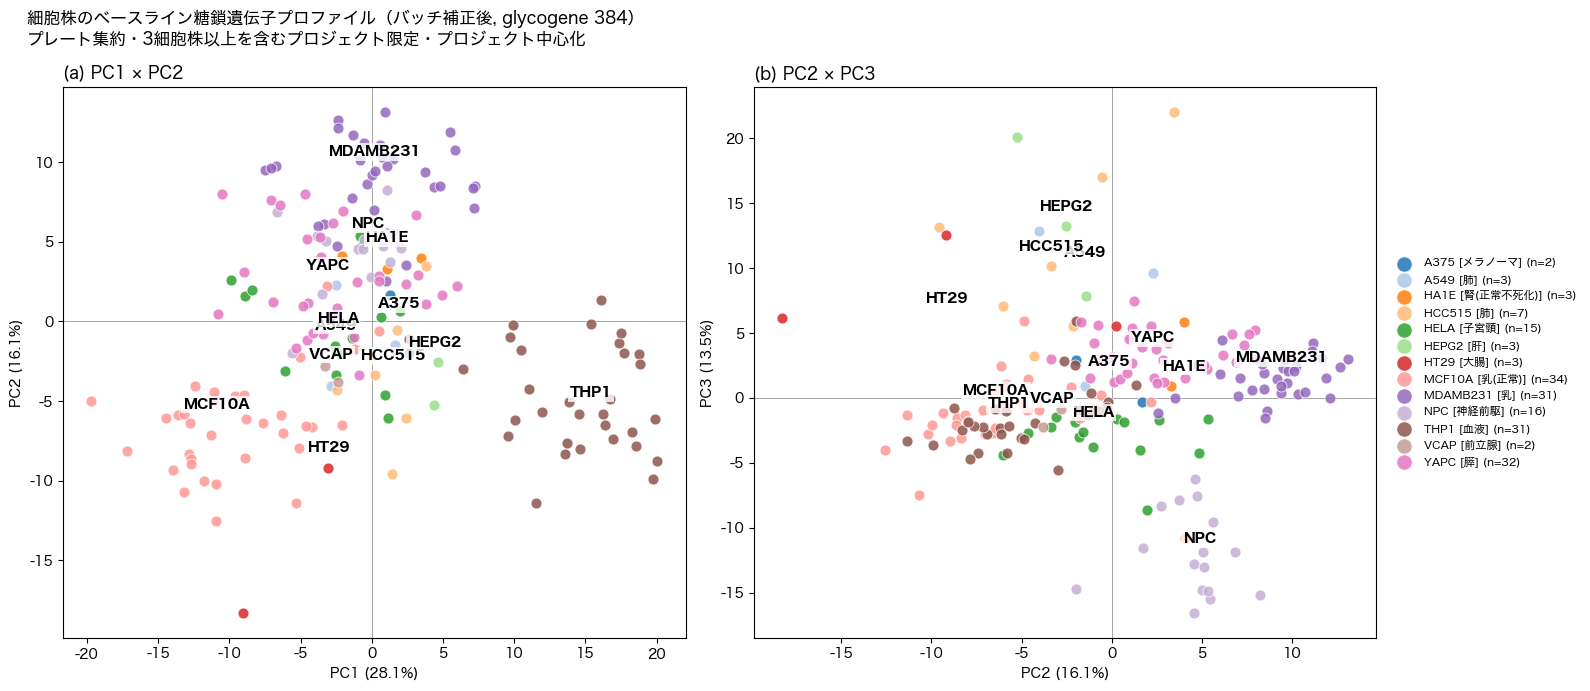

In [7]:
LINEAGE = {'HEPG2':'肝','HCC515':'肺','A549':'肺','MCF7':'乳','MDAMB231':'乳','MCF10A':'乳(正常)',
           'PC3':'前立腺','VCAP':'前立腺','A375':'メラノーマ','HT29':'大腸','HELA':'子宮頸',
           'YAPC':'膵','U2OS':'骨','THP1':'血液','NPC':'神経前駆','HA1E':'腎(正常不死化)'}

pca = PCA(n_components=10).fit(Msc)
Y = pca.transform(Msc)
cs_arr = np.asarray(cs)
print('寄与率 PC1-4:', np.round(pca.explained_variance_ratio_[:4], 3))
print('silhouette  =', round(silhouette_score(Y, cs_arr), 3))

cells_u = sorted(set(cs_arr))
cmap = plt.get_cmap('tab20')
color = {c: cmap(i % 20) for i, c in enumerate(cells_u)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (i, j) in zip(axes, [(0, 1), (1, 2)]):
    for c in cells_u:
        m = cs_arr == c
        ax.scatter(Y[m, i], Y[m, j], s=62, alpha=.85, color=color[c],
                   linewidths=.6, edgecolor='white',
                   label=f"{c} [{LINEAGE.get(c,'?')}] (n={m.sum()})" if (i, j) == (1, 2) else None)
    for c in cells_u:
        m = cs_arr == c
        ax.annotate(c, (np.median(Y[m, i]), np.median(Y[m, j])), fontsize=10,
                    fontweight='bold', zorder=6, xytext=(0, 11),
                    textcoords='offset points', ha='center',
                    bbox=dict(fc='white', ec='none', alpha=.8, pad=1.2))
    ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
    ax.axhline(0, lw=.5, color='gray', zorder=0)
    ax.axvline(0, lw=.5, color='gray', zorder=0)

axes[0].set_title('(a) PC1 × PC2', loc='left')
axes[1].set_title('(b) PC2 × PC3', loc='left')
fig.suptitle('細胞株のベースライン糖鎖遺伝子プロファイル（バッチ補正後, glycogene 384）\n'
             'プレート集約・3細胞株以上を含むプロジェクト限定・プロジェクト中心化',
             x=.02, ha='left', fontsize=12)
axes[1].legend(fontsize=8, markerscale=1.4, frameon=False,
               loc='center left', bbox_to_anchor=(1.01, .5))
plt.tight_layout()
savefig('fig_baseline_glycogene_pca')
plt.show()

In [8]:
pd.Series(cs_arr).value_counts().to_frame('プレート数')

,プレート数
MCF10A,34
YAPC,32
THP1,31
MDAMB231,31
NPC,16
HELA,15
HCC515,7
HA1E,3
A549,3
HEPG2,3


## 結論

- 対照サンプルの**絶対量**では、細胞株がバッチ補正後も分散の **63.9%** を説明する（silhouette 0.326）。
  薬剤応答の差分（z-score）が雲になるのは、z化でベースラインが引かれるためであり、
  パイプラインの不備ではない。
- **THP1（血液）が PC1 で独立**。浮遊系と接着系で糖鎖の作りが根本的に違う。
- **MCF10A（正常乳腺）と MDAMB231（乳がん）が同一組織でありながら分離**。
  「同一組織の正常 vs がんで糖鎖プログラムの素地が異なる」という本論文の前提を支持し、
  背骨を HEPG2 × PHH に置く判断とも構造が一致する。

## 制約

- バッチ補正のためにプロジェクトを絞った結果、**中核細胞株のプレート数が激減**した
  （HEPG2 は 4 プレート、PC3 は 1）。**この図は HEPG2 について何も言えない**。
  乳腺ペアが偶然よく揃っていただけである。
- 元データは DCIC の推論 RNA-seq であり、978 landmark の関数という制約は残る
  （`docs/set_based_aggregation_feasibility.md`）。ただし細胞株間のベースライン差は
  推論値でも十分大きく残る。

## 次

HEPG2 のプレート数を確保できるバッチの扱い方を検討する（プロジェクト限定を緩め、
別の方法でバッチを補正する）。